Code for the thesis, starts with application to financial data, and then Monte Carlo contaminated simulation

Financial Data 

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.optimize as opt
import scipy.stats as stat
import matplotlib.pyplot as plt

In [23]:
def isdf (t,yt,esd,sl,l,wt):
    t = float(t)
    w = wt*np.exp(t) + (1-wt)*esd
    theta = (-1/2*np.log(2*np.pi) -1/2*t - (1/(2*np.exp(t)))*yt**2) - (l/2)*(w-sl)**2
    return -theta

def eisd (data, omega, a, b, p00, p11, l, g, eta, n, c, eint, bv, k=1):
    pl = [0.5,0.5]
    p = []
    w=[]
    r0 = stat.norm(loc = 0, scale = np.sqrt(bv))
    r1 = stat.norm(loc = 0, scale = np.sqrt(bv*c))
    est = [eint]
    gas = []
    imp = []
    pred = g+eta*est[0]
    for i in range(len(data)):
        est_i = float(est[i])
        if not np.isfinite(est_i) or est_i <= 0:
            return None
        pi = (pl[0]*r0.pdf(data.iloc[i]))/(pl[0]*r0.pdf(data.iloc[i])+pl[1]*r1.pdf(data.iloc[i]))
        p.append(pi)
        pl[0] = p00*pi+(1-p11)*(1-pi)
        pl[1] = 1-pl[0]
        if i < n:
            pavg = np.mean(p)
        else:
            pavg = np.mean(p[(i-n):])
        esd = omega + (a/l)*((data.iloc[i]**2-est[i])/(2*est[i]))+b*np.log(est[i])
        if not np.isfinite(esd):
            return None
        wt = (2*pavg - 1)**2
        isd = opt.minimize_scalar(isdf,args=(data.iloc[i],np.exp(esd),pred,l,wt),bounds=(np.log(max(est[i], 1e-7)) - 5, np.log(max(est[i], 1e-7)) + 5),method="bounded")
        weighted_est = max(float(k*wt*np.exp(isd.x) + (1-k*wt)*np.exp(esd)), 1e-7)
        est.append(weighted_est)
        w.append(wt)
        gas.append(np.exp(esd))
        imp.append(np.exp(isd.x))
        pred = g+eta*est[i+1]
    return(gas, imp, est,w)



data = yf.download("^GSPC", start="2000-02-01", end="2026-01-01", auto_adjust=False)
data = data["Adj Close"]["^GSPC"].dropna()
data = np.log(data/data.shift(1)).dropna()
split = int(0.2 * len(data))
baseline_var = (data.iloc[:split]**2).mean()
eint = baseline_var
sample_data = data["2000-02-01":"2015-12-31"]
oos_data = data["2016-01-01":]

[*********************100%***********************]  1 of 1 completed


In [13]:
#justification of 4x in higher vol regime of Markov 
print((data["2008-01-01":"2008-12-31"]**2).mean()/baseline_var)
print((data["2020-01-01":"2020-12-31"]**2).mean()/baseline_var)

4.333849036335103
3.0842018192357945


Optimisation step

In [14]:
def gas_exp(data, omega, a, b, eint):
    est = [eint]
    for i in range(len(data)):
        y = data.iloc[i]
        sigma2_prev = est[i]
        h_prev = np.log(sigma2_prev)
        score_h = (y**2 - sigma2_prev) / (2 * sigma2_prev)
        h_new = omega + (a) * score_h + b * h_prev
        sigma2_new = float(np.exp(h_new))
        est.append(sigma2_new)
    return est

def gas_nll(params, data, eint):
    omega, a, b = params
    if not (0 < b < 1) or a <= 0:
        return 1e10
    est = gas_exp(data, omega, a, b, eint)
    nll = 0
    for i in range(1, len(est)):
        sigma2 = est[i-1]
        y = data.iloc[i-1]
        if not np.isfinite(sigma2) or sigma2 <= 0:
            return 1e10
        nll += 0.5*np.log(2*np.pi) + 0.5*np.log(sigma2) + y**2/(2*sigma2)
    return nll

def fit_gas(data, eint):
    x0 = [(1-0.95)*np.log(eint), 0.05, 0.95]
    bounds = [(-2, 2), (1e-6, 1), (0, 0.9999)]
    result = opt.minimize(gas_nll, x0, args=(data, eint),method='L-BFGS-B', bounds=bounds)
    return result

result = fit_gas(data, eint)
omega_hat, a_hat, b_hat = result.x

/var/folders/xd/vhg52hjj5wn2vqxyqgj2hzs80000gp/T/ipykernel_25519/846500855.py:9: RuntimeWarning: overflow encountered in exp
  sigma2_new = float(np.exp(h_new))
/var/folders/xd/vhg52hjj5wn2vqxyqgj2hzs80000gp/T/ipykernel_25519/846500855.py:7: RuntimeWarning: invalid value encountered in scalar divide
  score_h = (y**2 - sigma2_prev) / (2 * sigma2_prev)


In [16]:
def eisd_nll(params, data, n, c, eint, bv):
    omega, a, b, l, g, eta = params
    p00 = 0.5
    p11 = 0.5
    if not (0 < b < 1) or a <= 0 or l <= 0:
        return 1e10
    out = eisd(data, omega, a, b, p00, p11, l, g, eta, n, c, eint, bv)
    if out is None:
        return 1e10
    gas, imp, est, w = out
    nll = 0
    pred = g + eta*eint
    for i in range(len(data)-1):
        if not np.isfinite(pred) or pred <= 0:
            return 1e10
        nll += 0.5*np.log(2*np.pi) + 0.5*np.log(pred) + data.iloc[i]**2/(2*pred)
        pred = g + eta*est[i+1]
    return nll

def fit_eisd(data, n, c, eint, bv):
    x0 = np.array([-5.12649114e-02, 1.35967136e-01,  9.93196737e-01, 9.67982175e+00,  2.22547879e-05,  7.97827328e-01], dtype=float).ravel()
    result = opt.minimize(eisd_nll, x0, args=(data, n, c, eint, bv),method='L-BFGS-B', bounds=np.array([[-2.0, 2.0],[1e-6, 1.0],[0.5, 0.9999],[0.1, 100.0],[1e-10, 1e-2],[0.5, 0.9999]], dtype=float))
    return result

In [19]:
results_n_c = {}
for c in [3,4,5]:
        for i in [20,30,40,60,90]:
            resultnc = fit_eisd(sample_data, n=i, bv=baseline_var, eint=baseline_var, c=c)
            results_n_c[(i,c)] = {'fun': resultnc.fun,'params': dict(zip(['omega', 'a', 'b', 'l', 'g', 'eta'], resultnc.x))}
            print(f"Done with results for {i,c}")


Done with results for (20, 3)


/var/folders/xd/vhg52hjj5wn2vqxyqgj2hzs80000gp/T/ipykernel_25519/3742627048.py:4: RuntimeWarning: overflow encountered in scalar power
  theta = (-1/2*np.log(2*np.pi) -1/2*t - (1/(2*np.exp(t)))*yt**2) - (l/2)*(w-sl)**2
/Users/raiap/Documents/Projects/myenv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2356: RuntimeWarning: invalid value encountered in scalar subtract
  r = (xf - nfc) * (fx - ffulc)
/Users/raiap/Documents/Projects/myenv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2357: RuntimeWarning: invalid value encountered in scalar subtract
  q = (xf - fulc) * (fx - fnfc)
/var/folders/xd/vhg52hjj5wn2vqxyqgj2hzs80000gp/T/ipykernel_25519/3742627048.py:4: RuntimeWarning: overflow encountered in scalar multiply
  theta = (-1/2*np.log(2*np.pi) -1/2*t - (1/(2*np.exp(t)))*yt**2) - (l/2)*(w-sl)**2
/var/folders/xd/vhg52hjj5wn2vqxyqgj2hzs80000gp/T/ipykernel_25519/3742627048.py:3: RuntimeWarning: overflow encountered in exp
  w = wt*np.exp(t) + (1-wt)*esd
/var/folders/

Done with results for (30, 3)
Done with results for (40, 3)


/var/folders/xd/vhg52hjj5wn2vqxyqgj2hzs80000gp/T/ipykernel_25519/3742627048.py:33: RuntimeWarning: overflow encountered in exp
  isd = opt.minimize_scalar(isdf,args=(data.iloc[i],np.exp(esd),pred,l,wt),bounds=(np.log(max(est[i], 1e-7)) - 5, np.log(max(est[i], 1e-7)) + 5),method="bounded")
/var/folders/xd/vhg52hjj5wn2vqxyqgj2hzs80000gp/T/ipykernel_25519/3742627048.py:37: RuntimeWarning: overflow encountered in exp
  gas.append(np.exp(esd))


Done with results for (60, 3)


/Users/raiap/Documents/Projects/myenv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2358: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/raiap/Documents/Projects/myenv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2359: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


Done with results for (90, 3)
Done with results for (20, 4)
Done with results for (30, 4)
Done with results for (40, 4)
Done with results for (60, 4)
Done with results for (90, 4)
Done with results for (20, 5)
Done with results for (30, 5)
Done with results for (40, 5)
Done with results for (60, 5)
Done with results for (90, 5)


In [ ]:
z = 1.645

thresholds = [0.1, 0.2, 0.5, 0.9]
gas_ests_oos = gas_exp(oos_data, omega_hat, a_hat, b_hat, eint)
realized_oos = (oos_data**2).rolling(20).mean()

for c in [3,4,5]:
    print(f"c={c} results:")
    for thresh in thresholds:
        n_eisd = []
        for i in [20,30,40,60,90]:
            omegai, ai, bi, li, gi, etai = results_n_c[(i,c)]['params'].values()
            gasoi, impoi, estsi,wti = eisd(oos_data, omegai, ai, bi, 0.5,0.5, li, gi, etai, i, c, eint, baseline_var)
            var_eisd = z*np.sqrt(estsi)
            var_gas = z*np.sqrt(gas_ests_oos) 
            var_rl = z*np.sqrt(realized_oos)
            n_eisd.append(np.sum(np.abs(np.diff(var_eisd)/var_eisd[:-1]) > thresh))
        n_gas  = np.sum(np.abs(np.diff(var_gas)/var_gas[:-1]) > thresh)
        n_rl = np.sum(np.abs(np.diff(var_rl)/var_rl[:-1]) > thresh)
        print(f"Threshold {thresh:.0%}: EISD={n_eisd}, GAS={n_gas}, Realized={n_rl}")

c=3 results:
Threshold 10%: EISD=[np.int64(65), np.int64(59), np.int64(57), np.int64(46), np.int64(162)], GAS=128, Realized=245
Threshold 20%: EISD=[np.int64(28), np.int64(20), np.int64(18), np.int64(18), np.int64(70)], GAS=50, Realized=61
Threshold 50%: EISD=[np.int64(6), np.int64(2), np.int64(1), np.int64(2), np.int64(18)], GAS=18, Realized=9
Threshold 90%: EISD=[np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(11)], GAS=11, Realized=3
c=4 results:
Threshold 10%: EISD=[np.int64(132), np.int64(128), np.int64(125), np.int64(80), np.int64(95)], GAS=128, Realized=245
Threshold 20%: EISD=[np.int64(51), np.int64(48), np.int64(47), np.int64(35), np.int64(33)], GAS=50, Realized=61
Threshold 50%: EISD=[np.int64(14), np.int64(13), np.int64(13), np.int64(9), np.int64(11)], GAS=18, Realized=9
Threshold 90%: EISD=[np.int64(4), np.int64(3), np.int64(3), np.int64(1), np.int64(1)], GAS=11, Realized=3
c=5 results:
Threshold 10%: EISD=[np.int64(190), np.int64(182), np.int64(177), np.int64(

We check the EISD vs realized vs GAS. We also disprove the step size shrinkage caused by l in EISD to be the driver of this change, as pure gas with the step size of EISD explicit step is not nearly as responsive.

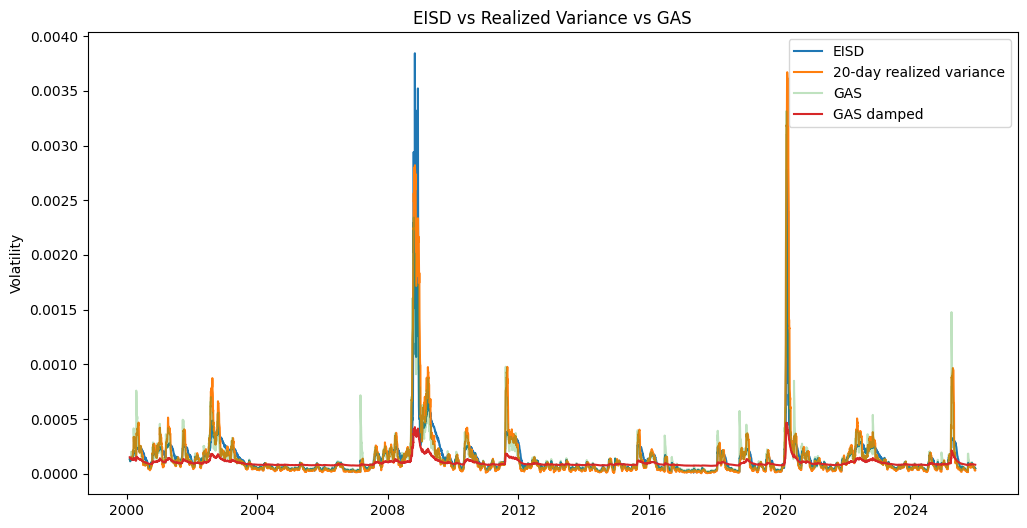

In [87]:
omega, a, b, l, g, eta = results_n_c[(30,4)]['params'].values()
gas_ests = gas_exp(data, omega_hat, a_hat, b_hat, eint)
gaso, impo, ests,wt = eisd(data, omega, a, b, 0.5,0.5, l, g, eta, 30, 4, eint, baseline_var)

n=40
a_damped = a/l
gas_ests_damped = gas_exp(data, omega_hat, a_damped, b_hat, eint)

realized = (data**2).rolling(20).mean()

plt.figure(figsize=(12,6))
plt.plot(data.index, ests[1:], label="EISD")
#plt.plot(data.index, ests_even[1:], label="EISD even")
#plt.plot(data.index, gaso, label="GASO")
#plt.plot(data.index, impo, label="IMPO")
plt.plot(data.index, realized,label="20-day realized variance")
plt.plot(data.index, gas_ests[1:],label="GAS",alpha=0.3)
plt.plot(data.index, gas_ests_damped[1:],label="GAS damped")
plt.legend()
plt.ylabel("Volatility")
plt.title("EISD vs Realized Variance vs GAS")
plt.show()

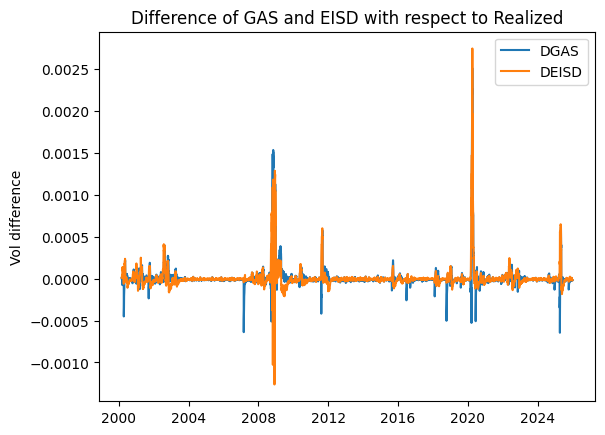

In [84]:
diffs = np.array(gas_ests) - np.array(ests)
dgas = np.array(realized) - np.array(gas_ests[1:])
deisd = np.array(realized) - np.array(ests[1:])
#plt.plot(data.index, diffs[1:])
plt.plot(data.index, dgas, label = "DGAS")
plt.plot(data.index, deisd, label = "DEISD")
plt.legend()
plt.ylabel("Vol difference")
plt.title("Difference of GAS and EISD with respect to Realized")
plt.show()

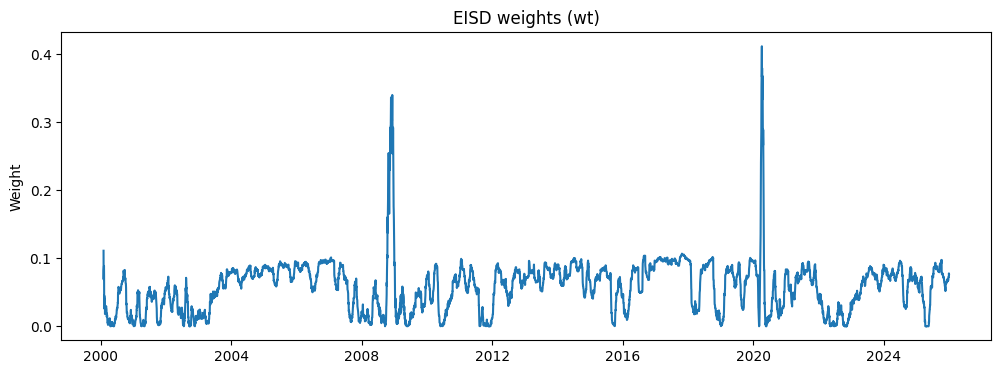

In [85]:
plt.figure(figsize=(12,4))
plt.plot(data.index, wt)
plt.title("EISD weights (wt)")
plt.ylabel("Weight")
plt.show()

In [90]:
oos_length = len(oos_data)
gasi, impi, estsi,wti = eisd(oos_data, omega, a, b, 0.5,0.5, l, g, eta, 30, 4, eint, baseline_var)
gas_ests_oos = gas_exp(oos_data, omega_hat, a_hat, b_hat, eint)
estsi = np.array(estsi)

oos_ests_pred = g + eta * estsi[:-1]  
oos_realized = (oos_data**2).rolling(20).mean().iloc[20:] 
oos_ests_pred = oos_ests_pred[20:]  

oos_gas_pred = gas_ests_oos[:-1]  
oos_gas_pred = oos_gas_pred[20:] 

QLIKEe = oos_ests_pred / oos_realized - np.log(oos_ests_pred / oos_realized) - 1
QLIKEg = oos_gas_pred / oos_realized - np.log(oos_gas_pred / oos_realized) - 1
print(f"EISD QLIKE: {np.mean(QLIKEe):.4f}")
print(f"GAS QLIKE:  {np.mean(QLIKEg):.4f}")

dql = QLIKEe - QLIKEg
t_stat, pv = stat.ttest_1samp(dql, popmean=0)
print(f"DM QLIKE: t={t_stat:.4f}, p={pv:.4f}")

MAEe = np.abs(oos_ests_pred - oos_realized)
MAEg = np.abs(oos_gas_pred - oos_realized)
print(f"EISD MAE: {np.mean(MAEe):.4e}")
print(f"GAS MAE:  {np.mean(MAEg):.4e}")

dmae = MAEe - MAEg
t_stat, pv = stat.ttest_1samp(dmae, popmean=0)
print(f"DM MAE: t={t_stat:.4f}, p={pv:.4f}")

EISD QLIKE: 0.1499
GAS QLIKE:  0.1169
DM QLIKE: t=9.3782, p=0.0000
EISD MAE: 5.4492e-05
GAS MAE:  4.2960e-05
DM MAE: t=6.8537, p=0.0000


VaR calculations

Monte Carlo

The main dependence is on the damped gas, as there is no persistence that warrents the need for the ISD to kick in.

In [80]:
def clean_generator(T, s2, seed = 42):
    rng = np.random.default_rng(seed)
    cldata = rng.normal(0,np.sqrt(s2), size = T)
    return cldata

def contaminator(clean_data, eps, c, T, s2, seed = 100):
    rng = np.random.default_rng(seed)
    rat = rng.binomial(1,eps, size = T)
    contam = rng.normal(0,np.sqrt(c*s2),size = T)
    codata = (1-rat)*clean_data + rat*contam
    return codata, rat

def neg_log_score(s2, y):
    s2 = np.array(s2)
    y = np.array(y)
    return 0.5 * np.log(2 * np.pi * s2) + 0.5 * y**2 / s2

mse_eisd = 0
mse_gas = 0
mse_eisd_local = 0
mse_gas_local = 0

nls_eisd = 0
nls_gas = 0
nls_eisd_local = 0
nls_gas_local = 0

valid_eisd = 0
valid_gas = 0
valid_eisd_local = 0
valid_gas_local = 0

var_eisd_avg = np.zeros(5)
var_gas_avg = np.zeros(5)
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

nums=500

for i in range(nums):
    clean_data_train = clean_generator(1000,0.0001,seed = i)
    contaminated_data_train, rats = contaminator(clean_data_train,0.05,9,1000,0.0001, seed = i+100)
    bv_mc = np.var(contaminated_data_train[:(200)])
    eint_mc = bv_mc
    gasmc, impmc, estsmc,wtmc = eisd(pd.Series(contaminated_data_train), omega, a, b, 0.5, 0.5, l, g, eta, 40, 5, eint_mc, bv_mc)
    gas_estsmc = gas_exp(pd.Series(contaminated_data_train), omega_hat, a_hat, b_hat, eint_mc)

    contams = np.where(rats == 1)[0]
    contams_local = np.unique(np.concatenate([contams+j for j in range(5)]))
    contams_local = contams_local[contams_local<1000]

    var_eisd = z * np.sqrt(estsmc)
    var_gas  = z * np.sqrt(gas_estsmc)
    
    path_mse_eisd = np.mean((pd.array(estsmc[1:])-0.0001)**2)
    path_mse_gas = np.mean((pd.array(gas_estsmc[1:])-0.0001)**2)
    path_mse_eisd_local = np.mean((np.array(estsmc)[contams_local]-0.0001)**2)
    path_mse_gas_local = np.mean((np.array(gas_estsmc)[contams_local]-0.0001)**2)

    path_nls_eisd = np.mean(neg_log_score(estsmc[1:],contaminated_data_train))
    path_nls_gas = np.mean(neg_log_score(gas_estsmc[1:],contaminated_data_train))
    path_nls_eisd_local = np.mean(neg_log_score(np.array(estsmc)[contams_local],np.array(contaminated_data_train)[contams_local]))
    path_nls_gas_local = np.mean(neg_log_score(np.array(gas_estsmc)[contams_local],np.array(contaminated_data_train)[contams_local]))

    if path_mse_eisd < 0.00001 and np.isfinite(path_mse_eisd):
        nls_eisd += path_nls_eisd
        mse_eisd += path_mse_eisd
        valid_eisd += 1
        for i in range(len(thresholds)):
            var_eisd_avg[i] += np.sum(np.abs(np.diff(var_eisd)/var_eisd[:-1]) > thresholds[i])
            var_gas_avg[i]  += np.sum(np.abs(np.diff(var_gas)/var_gas[:-1]) > thresholds[i])
        

    if path_mse_gas < 0.00001 and np.isfinite(path_mse_gas):
        nls_gas += path_nls_gas
        mse_gas += path_mse_gas
        valid_gas += 1
    
    if path_mse_eisd_local < 0.00001 and np.isfinite(path_mse_eisd_local):
        nls_eisd_local += path_nls_eisd_local
        mse_eisd_local += path_mse_eisd_local
        valid_eisd_local += 1

    if path_mse_gas_local < 0.00001 and np.isfinite(path_mse_gas_local):
        nls_gas_local += path_nls_gas_local
        mse_gas_local += path_mse_gas_local
        valid_gas_local += 1
        

mean_mse_eisd = mse_eisd/valid_eisd
mean_mse_gas = mse_gas/valid_gas
mean_mse_eisd_local = mse_eisd_local/valid_eisd_local
mean_mse_gas_local = mse_gas_local/valid_gas_local

mean_nls_eisd = nls_eisd/valid_eisd
mean_nls_gas = nls_gas/valid_gas
mean_nls_eisd_local = nls_eisd_local/valid_eisd_local
mean_nls_gas_local = nls_gas_local/valid_gas_local

var_eisd_avg = var_eisd_avg/valid_eisd
var_gas_avg = var_gas_avg/valid_gas

#print(mean_mse_eisd,mean_mse_gas,mean_mse_eisd_local,mean_mse_gas_local,mean_nls_eisd,mean_nls_gas,mean_nls_eisd_local,mean_nls_gas_local)
#print(valid_eisd,valid_eisd_local,valid_gas,valid_gas_local)



In [81]:
print(mean_nls_eisd,mean_nls_gas,mean_nls_eisd_local,mean_nls_gas_local)
print(valid_eisd,valid_eisd_local,valid_gas,valid_gas_local)
print(mean_mse_eisd,mean_mse_gas,mean_mse_eisd_local,mean_mse_gas_local)

-3.0916119427436297 -3.1142678152345544 -2.4217386336825495 -2.341844963150495
500 500 471 442
6.90194721331437e-09 5.745582335691171e-07 1.2526087921661886e-08 8.930174321148027e-07


In [82]:
print(var_eisd_avg,var_gas_avg)

[39.128 22.16  14.466 10.298  7.91 ] [66.28237792 41.45010616 29.14012739 22.35456476 18.16348195]


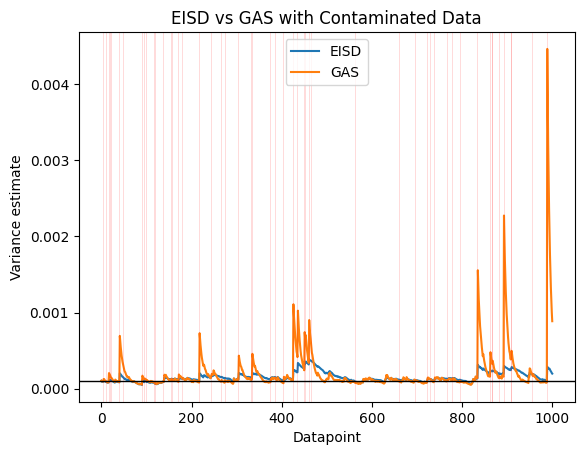

In [79]:
clean_data_train = clean_generator(1000,0.0001)
contaminated_data_train, rats = contaminator(clean_data_train,0.05,9,1000,0.0001)
bv_mc = np.var(contaminated_data_train[:(200)])
eint_mc = bv_mc

gasmc, impmc, estsmc,wtmc = eisd(pd.Series(contaminated_data_train), omega, a, b, 0.5, 0.5, l, g, eta, 40, 5, eint_mc, bv_mc)
gas_estsmc = gas_exp(pd.Series(contaminated_data_train), omega_hat, a_hat, b_hat, eint_mc)

contams = np.where(rats == 1)[0]

plt.plot(estsmc, label = 'EISD')
plt.plot(gas_estsmc, label = 'GAS')
for i in contams:
    plt.axvline(x=i, color='red', alpha=0.2, linewidth=0.5)
plt.axhline(y=0.0001, color='black', alpha=1, linewidth=1)
plt.title("EISD vs GAS with Contaminated Data")
plt.legend()
plt.ylabel("Variance estimate")
plt.xlabel("Datapoint")
plt.show()